In [16]:
import matplotlib.pyplot as plt
import numpy as np

### Evoluzione della distribuzione delle velocità

In [17]:
def boltzmann(v, T):
    return np.power(2*np.pi*T, -3/2)*4*np.pi*np.power(v,2)*np.exp(-np.power(v,2)/(2*T))

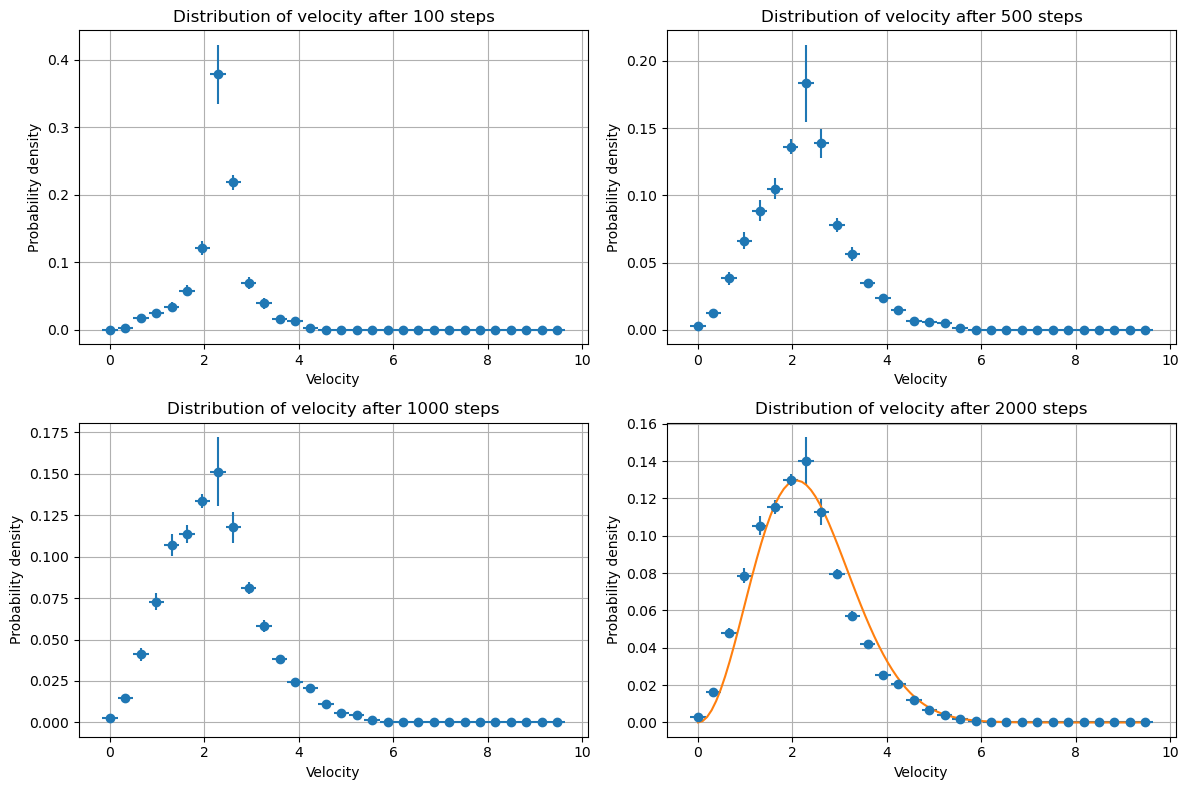

In [ ]:
fig, axx = plt.subplots(2, 2, figsize=(12, 8))
axx = axx.flatten()

v_temp = np.loadtxt('../OUTPUT/temperature.dat', usecols=2)
steps = [100, 500, 1000, 2000]

for i, ax in enumerate(axx):
    n_steps = steps[i]
    v, average, errors = np.loadtxt(f'../OUTPUT/pofv{n_steps}.dat', unpack=True)
    dv = (v[1] - v[0]) * 0.5

    # Traccia i dati del singolo file
    ax.errorbar(v,average,xerr=dv,yerr=errors,fmt='o')
    ax.set_xlabel('Velocity')
    ax.set_ylabel('Probability density')
    ax.set_title(f'Distribution of velocity after {n_steps} steps')
    ax.grid(True)

    if i == 3:
        x = np.linspace(0.0, v[-1], 100)
        temp = v_temp[-1]
        fit_func_raw = boltzmann(x, temp)
        # Calcolo l'area della curva sperimentale per scalare del fattore giusto la curva analitica
        area_dati = np.trapezoid(average, v)
        fit_func = fit_func_raw * (area_dati)
        ax.plot(x, fit_func)

plt.tight_layout()
plt.show()

### Commenti
I grafici riportano l'evoluzione della distribuzione dei moduli delle velocità delle particelle al termine di ciascuna simulazione.

Ciascuna simulazione partiva da una configurazione a entropia molto bassa, con i moduli delle velocità distribuiti come una delta di Dirac attorno a  $\pm v_{T^*}$. Man mano che si aumentano gli steps delle simulazioni la distribuzione assomiglia sempre più ad una distribuzione di Maxwell-Boltzmann. 